<div dir="rtl" style="text-align:center; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:28px; font-weight:bold; margin:20px 0; color:#2e86de;">
تحلیل‌های آماری
</div>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
df = pd.read_csv("Divar.csv")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13124\1381234337.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Divar.csv")


<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۱: رسم توزیع آگهی‌های موجود در دسته‌های مختلف برای دسته‌بندی سطح دو و سطح سه
</div>

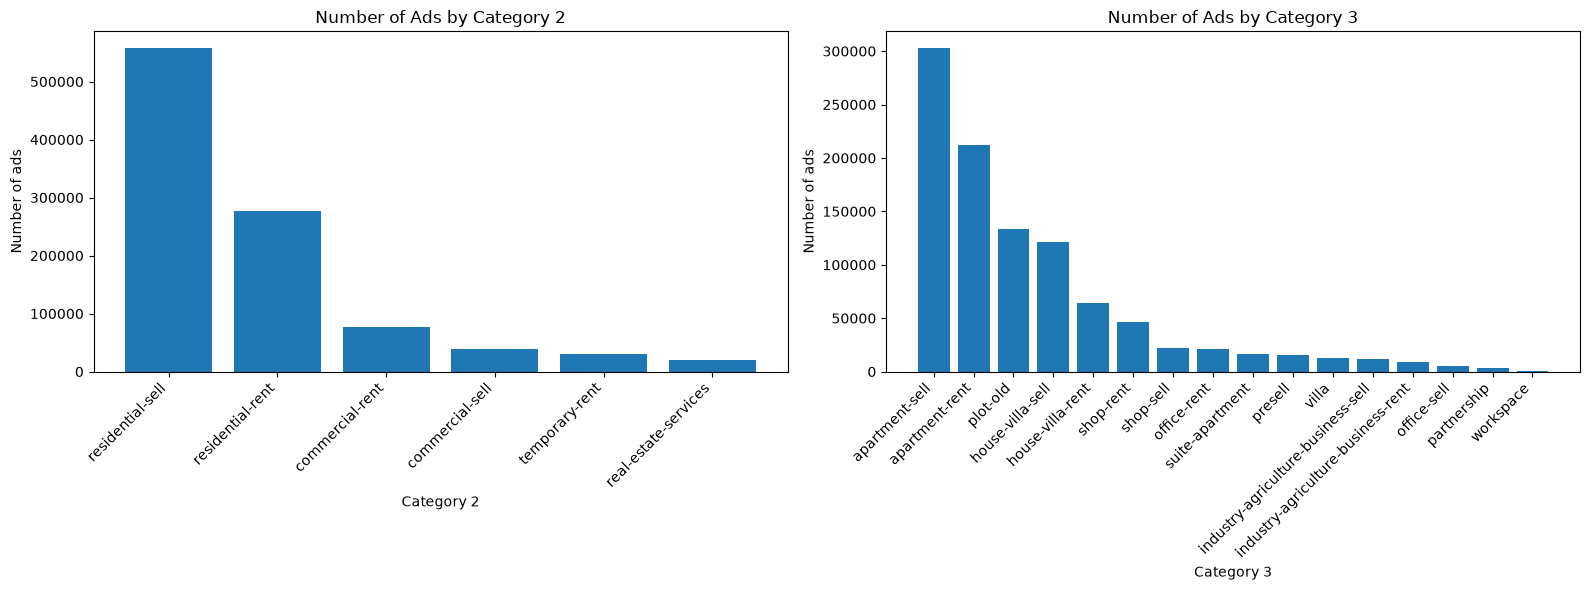

In [3]:
ad_count_by_cat2 = df['cat2_slug'].value_counts()
ad_count_by_cat3 = df['cat3_slug'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(ad_count_by_cat2.index, ad_count_by_cat2.values)
ax1.set_ylabel('Number of ads')
ax1.set_xlabel('Category 2')
ax1.set_title('Number of Ads by Category 2')

ax2.bar(ad_count_by_cat3.index, ad_count_by_cat3.values)
ax2.set_ylabel('Number of ads')
ax2.set_xlabel('Category 3')
ax2.set_title('Number of Ads by Category 3')

for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

for label in ax2.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
در هر دو نمودار، توزیع آگهی‌ها بین دسته‌های مختلف یکسان نیست. در سطح دوم، آگهی‌های فروش و اجاره مسکونی بیشترین فراوانی را دارند و در سطح سوم نیز فروش و اجاره آپارتمان در رتبه‌های اول قرار گرفته‌اند. این موضوع نشان‌دهنده‌ی تمرکز بخش عمده‌ای از داده‌ها بر بازار املاک مسکونی، به‌ویژه آپارتمان‌ها، است.
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۲: هیستوگرام سال ساخت
</div>

In [5]:
#Q2

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۳: بررسی تعداد آگهی‌های منتشر شده در ماه‌های مختلف را برای فروش و اجاره
</div>

In [4]:
#Q3

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
 سوال ۴: توزیع قیمت فروش‌ (price_value) برای دسته‌بندی‌های سطح سه
</div>

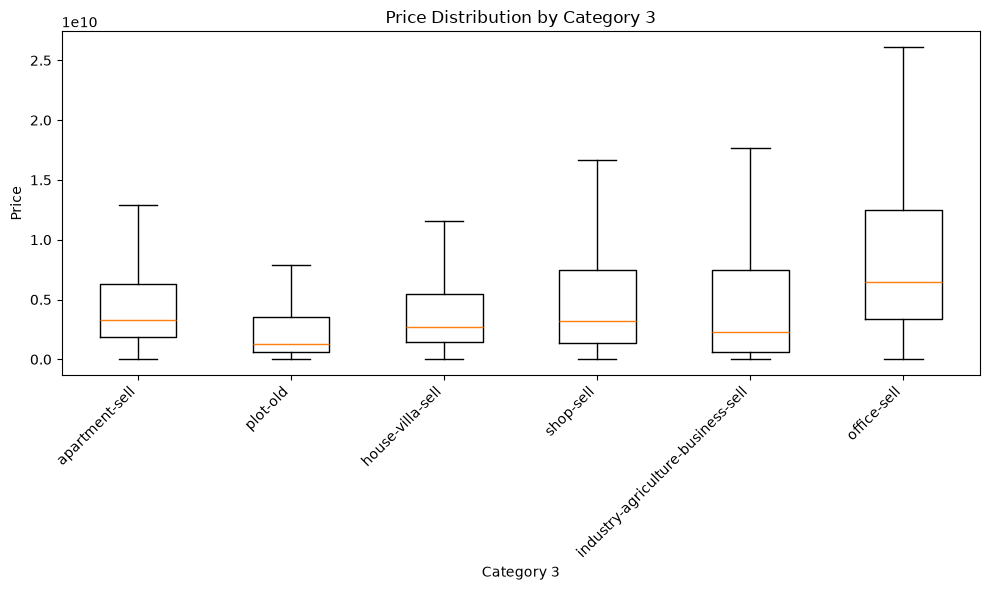

In [6]:
df_sell = df['cat2_slug'].fillna('')
df_sell = df[df['cat2_slug'].str.contains('sell')]
cat3_order = df_sell['cat3_slug'].value_counts().index

df_sell = df_sell[
    (df_sell['price_value'] > 0) &
    (df_sell['price_value'] < 1e11)
]

price_by_cat3 = [
    df_sell[df_sell['cat3_slug'] == cat]['price_value'].dropna().values
    for cat in cat3_order
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(
    price_by_cat3,
    tick_labels=cat3_order,
    showfliers=False
)

ax.set_ylabel('Price')
ax.set_xlabel('Category 3')
ax.set_title('Price Distribution by Category 3')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
این نمودار نشان می‌دهد که قیمت املاک در دسته‌های مختلف سطح سوم تفاوت قابل‌توجهی دارد. دسته‌ی Office بالاترین میانه قیمت را دارد، در حالی که plot-old کمترین میانه را نشان می‌دهد. همچنین پراکندگی قیمت در دسته‌های مختلف متفاوت است و در برخی دسته‌ها دامنه تغییرات قیمت بیشتر است. مقادیر پرت برای خوانایی بهتر در نمودار نمایش داده نشده‌اند.
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
 سوال ۵: رسیم آگهی‌های هر منطقه بر روی نقشه‌ی جغرافیایی heatmap 
</div>

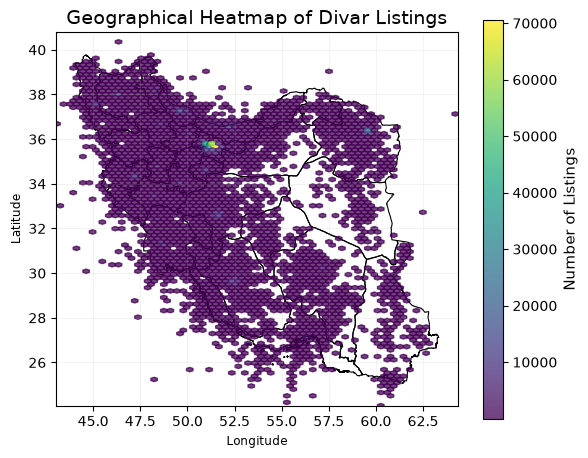

In [14]:
iran = gpd.read_file(
    "https://raw.githubusercontent.com/ssepehrnoush/Iran-geojson-map-boundaries/master/ir_states_boundaries_coordinates.geojson"
)

map_df = df.dropna(
    subset=['location_latitude', 'location_longitude']
).copy()

fig, ax = plt.subplots(figsize=(6, 6))

iran.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=0.8
)

hb = ax.hexbin(
    map_df['location_longitude'],
    map_df['location_latitude'],
    gridsize=100,
    cmap='viridis',
    mincnt=1,
    alpha=0.75
)

cbar = fig.colorbar(
    hb,
    ax=ax,
    shrink=0.7
)

cbar.set_label(
    'Number of Listings',
    fontsize=11
)

minx, miny, maxx, maxy = iran.total_bounds

ax.set_xlim(minx - 1, maxx + 1)
ax.set_ylim(miny - 1, maxy + 1)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.set_title(
    'Geographical Heatmap of Divar Listings',
    fontsize=14
)

ax.grid(
    alpha=0.15
)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;"> آگهی‌ها عمدتاً در نیمه غربی و شمالی کشور متمرکز هستند و نقشه یک الگوی جغرافیایی روشن نشان می‌دهد. بیشترین تراکم (نقطه زرد و سبز، حدود ۷۰ هزار آگهی) در حوالی طول ۵۱ و عرض ۳۵٫۷ قرار دارد که با تهران مطابقت می‌کند؛ یعنی بازار آگهی به‌شدت متمرکز در پایتخت است و بقیه مناطق در مقایسه با آن تراکم بسیار کمتری دارند (رنگ بنفش تیره، زیر ۱۰ هزار). در مقابل، مناطق مرکزی و شرقی (کویر و بیابان‌های داخلی) تقریباً خالی هستند که با تراکم پایین جمعیت آن نواحی همخوانی دارد. به‌طور کلی توزیع آگهی‌ها با پراکندگی جمعیت و شهرهای بزرگ هم‌راستاست و تهران یک نقطه پرت (outlier) از نظر تعداد است. </div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۶: ترند میانگین قیمت اجاره بر حسب ماه‌های قرار گرفتن آگهی‌ها
</div>

In [ ]:
#Q6

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۷: محاسبه قیمت حقیقی ه ازای میانگین مبلغ قیمت(price_value) در سال‌های ۱۴۰۰ تا ۱۴۰۳ 
</div>

In [ ]:
#Q7

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۸: رسم ماتریس هم‌بستگی برای مبلغ قیمت، متراژ زمین، زیربنا، ظرفیت نفرات، تعداد اتاق‌ها و طول و عرض جغرافیایی
</div>

In [ ]:
#Q8

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۹: توزیع جغرافیایی خانه‌های دارای امکانات (بالکن، آسانسور، نگهبان، باربیکیو و استخر)
</div>

In [ ]:
#Q9

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>